# Regression Analysis of Bird Populations

This notebook uses `birdsong_df` to study how seasonal temperature, natural disasters, urban development, and precipitation relate to bird population counts in Colorado.

Questions answered:
3. For each of the four seasons, what is the relationship between average temperature and the number of birds observed?
4. Can we predict the impact of natural disasters on bird population counts?
5. Can we predict the impact of urban development on bird population counts?
6. Does the amount of precipitation per year impact the number of birds in a region?

In [25]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid')


In [26]:
# Load birdsong_df from memory when available; otherwise fall back to the cleaned project dataset.
if 'birdsong_df' not in globals():
    birdsong_df = pd.read_csv('../data/birdsong.csv')
else:
    birdsong_df = birdsong_df.copy()

print(f'birdsong_df shape: {birdsong_df.shape}')
display(birdsong_df.head())


birdsong_df shape: (349430, 14)


,common_name,date,bird_count,county,family,total_monthly_precipitation,monthly_max_temp,monthly_min_temp,urban_population_level,county_total_population,is_fire,is_flood,bird_count_adjusted_for_population,season
0,Band-tailed Pigeon,2021-01,1.0,Garfield,Pigeons and Doves,23.015789,1.412222,-10.458889,4,62178.480,0,0,0.000016,Winter
1,Pine Warbler,2021-01,1.0,Boulder,New World Warblers,9.873737,3.830000,-8.277778,5,333404.064,0,0,0.000003,Winter
2,White-winged Scoter,2021-01,1.0,Larimer,"Ducks, Geese, and Waterfowl",10.825893,1.854118,-10.457222,5,361938.528,0,0,0.000003,Winter
3,Brown Thrasher,2021-01,1.0,Boulder,Mockingbirds and Thrashers,9.873737,3.830000,-8.277778,5,333404.064,0,0,0.000003,Winter
4,Bonaparte's Gull,2021-01,2.0,Pueblo,"Gulls, Terns, and Skimmers",14.127778,8.566667,-8.400000,5,169507.296,0,0,0.000012,Winter


## Shared Utilities

In [27]:
def snapshot(df, label, n=5, max_cols=12):
    print()
    print(label)
    print(f'Shape: {df.shape}')
    display(df.iloc[:n, :max_cols])
    if df.shape[1] > max_cols:
        print(f'Showing first {max_cols} of {df.shape[1]} columns.')


def render_markdown(text):
    display(Markdown(text))


season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}


## Transformation 1: Basic Type Cleanup

- Ensure `date` is a proper datetime value before extracting year, month, or season.
- Ensure numeric predictor values are of consistent numeric types.


In [28]:
snapshot(birdsong_df, 'Before Transformation 1')

model_source_df = birdsong_df.copy()
model_source_df['date'] = pd.to_datetime(model_source_df['date'])

numeric_cols = [
    'bird_count',
    'total_monthly_precipitation',
    'monthly_max_temp',
    'monthly_min_temp',
    'urban_population_level',
    'county_total_population',
    'is_fire',
    'is_flood'
]

for col in numeric_cols:
    model_source_df[col] = pd.to_numeric(model_source_df[col], errors='coerce')

model_source_df['year'] = model_source_df['date'].dt.year
model_source_df['month'] = model_source_df['date'].dt.month
model_source_df['season'] = model_source_df.get('season', model_source_df['month'].map(season_map))
model_source_df['season'] = model_source_df['season'].replace({'Fall': 'Autumn'})

snapshot(
    model_source_df[['common_name', 'county', 'date', 'year', 'month', 'season', 'bird_count', 'monthly_max_temp', 'monthly_min_temp']],
    'After Transformation 1'
)



Before Transformation 1
Shape: (349430, 14)


,common_name,date,bird_count,county,family,total_monthly_precipitation,monthly_max_temp,monthly_min_temp,urban_population_level,county_total_population,is_fire,is_flood
0,Band-tailed Pigeon,2021-01,1.0,Garfield,Pigeons and Doves,23.015789,1.412222,-10.458889,4,62178.480,0,0
1,Pine Warbler,2021-01,1.0,Boulder,New World Warblers,9.873737,3.830000,-8.277778,5,333404.064,0,0
2,White-winged Scoter,2021-01,1.0,Larimer,"Ducks, Geese, and Waterfowl",10.825893,1.854118,-10.457222,5,361938.528,0,0
3,Brown Thrasher,2021-01,1.0,Boulder,Mockingbirds and Thrashers,9.873737,3.830000,-8.277778,5,333404.064,0,0
4,Bonaparte's Gull,2021-01,2.0,Pueblo,"Gulls, Terns, and Skimmers",14.127778,8.566667,-8.400000,5,169507.296,0,0


Showing first 12 of 14 columns.

After Transformation 1
Shape: (349430, 9)


,common_name,county,date,year,month,season,bird_count,monthly_max_temp,monthly_min_temp
0,Band-tailed Pigeon,Garfield,2021-01-01,2021,1,Winter,1.0,1.412222,-10.458889
1,Pine Warbler,Boulder,2021-01-01,2021,1,Winter,1.0,3.830000,-8.277778
2,White-winged Scoter,Larimer,2021-01-01,2021,1,Winter,1.0,1.854118,-10.457222
3,Brown Thrasher,Boulder,2021-01-01,2021,1,Winter,1.0,3.830000,-8.277778
4,Bonaparte's Gull,Pueblo,2021-01-01,2021,1,Winter,2.0,8.566667,-8.400000


## Transformation 2: Aggregate to County-Month Level

- The original data is observation/species level, so weather and disaster values are repeated many times within a county-month.
- Aggregating to county-month prevents the model from overweighting duplicated environmental conditions.
- Bird counts are summed because the goal is to model observed bird population counts.

In [29]:
snapshot(
    model_source_df[['county', 'date', 'bird_count', 'total_monthly_precipitation', 'monthly_max_temp', 'monthly_min_temp', 'urban_population_level', 'is_fire', 'is_flood']],
    'Before Transformation 2'
)

county_month_df = (
    model_source_df
    .groupby(['county', 'date'], as_index=False)
    .agg({
        'bird_count': 'sum',
        'total_monthly_precipitation': 'mean',
        'monthly_max_temp': 'mean',
        'monthly_min_temp': 'mean',
        'urban_population_level': 'mean',
        'county_total_population': 'mean',
        'is_fire': 'max',
        'is_flood': 'max'
    })
)

county_month_df['year'] = county_month_df['date'].dt.year
county_month_df['month'] = county_month_df['date'].dt.month
county_month_df['season'] = county_month_df['month'].map(season_map)

snapshot(county_month_df, 'After Transformation 2')



Before Transformation 2
Shape: (349430, 9)


,county,date,bird_count,total_monthly_precipitation,monthly_max_temp,monthly_min_temp,urban_population_level,is_fire,is_flood
0,Garfield,2021-01-01,1.0,23.015789,1.412222,-10.458889,4,0,0
1,Boulder,2021-01-01,1.0,9.873737,3.830000,-8.277778,5,0,0
2,Larimer,2021-01-01,1.0,10.825893,1.854118,-10.457222,5,0,0
3,Boulder,2021-01-01,1.0,9.873737,3.830000,-8.277778,5,0,0
4,Pueblo,2021-01-01,2.0,14.127778,8.566667,-8.400000,5,0,0



After Transformation 2
Shape: (3717, 13)


,county,date,bird_count,total_monthly_precipitation,monthly_max_temp,monthly_min_temp,urban_population_level,county_total_population,is_fire,is_flood,year,month
0,Adams,2021-01-01,410.0,1.50,8.038611,-6.441190,5.0,523728.576,0,0,2021,1
1,Adams,2021-02-01,600.0,5.40,5.077778,-9.320278,5.0,523728.576,0,0,2021,2
2,Adams,2021-03-01,105.0,45.70,11.264028,-3.354056,5.0,523728.576,0,0,2021,3
3,Adams,2021-04-01,222.0,28.85,14.906611,-0.706306,5.0,523728.576,0,0,2021,4
4,Adams,2021-05-01,253.0,68.40,19.938750,5.737639,5.0,523728.576,0,0,2021,5


Showing first 12 of 13 columns.


## Transformation 3: Engineer County-Season Features

- Question 3 is explicitly seasonal, so we build a county-season dataset.
- Yearly precipitation is needed for Question 6.
- Disaster and urban-development variables become easier to interpret after aggregation.


In [30]:
snapshot(county_month_df, 'Before Transformation 3')

county_season_df = (
    county_month_df
    .groupby(['county', 'year', 'season'], as_index=False)
    .agg({
        'bird_count': 'sum',
        'total_monthly_precipitation': 'sum',
        'monthly_max_temp': 'mean',
        'monthly_min_temp': 'mean',
        'urban_population_level': 'mean',
        'county_total_population': 'mean',
        'is_fire': 'sum',
        'is_flood': 'sum'
    })
)

county_season_df['avg_season_temp'] = (
    county_season_df['monthly_max_temp'] + county_season_df['monthly_min_temp']
) / 2
county_season_df['annual_precipitation'] = county_season_df.groupby(['county', 'year'])['total_monthly_precipitation'].transform('sum')
county_season_df['natural_disaster_months'] = county_season_df['is_fire'] + county_season_df['is_flood']
county_season_df['bird_count_per_100k'] = (
    county_season_df['bird_count'] / county_season_df['county_total_population']
) * 100000

snapshot(county_season_df, 'After Transformation 3')



Before Transformation 3
Shape: (3717, 13)


,county,date,bird_count,total_monthly_precipitation,monthly_max_temp,monthly_min_temp,urban_population_level,county_total_population,is_fire,is_flood,year,month
0,Adams,2021-01-01,410.0,1.50,8.038611,-6.441190,5.0,523728.576,0,0,2021,1
1,Adams,2021-02-01,600.0,5.40,5.077778,-9.320278,5.0,523728.576,0,0,2021,2
2,Adams,2021-03-01,105.0,45.70,11.264028,-3.354056,5.0,523728.576,0,0,2021,3
3,Adams,2021-04-01,222.0,28.85,14.906611,-0.706306,5.0,523728.576,0,0,2021,4
4,Adams,2021-05-01,253.0,68.40,19.938750,5.737639,5.0,523728.576,0,0,2021,5


Showing first 12 of 13 columns.

After Transformation 3
Shape: (1277, 15)


,county,year,season,bird_count,total_monthly_precipitation,monthly_max_temp,monthly_min_temp,urban_population_level,county_total_population,is_fire,is_flood,avg_season_temp
0,Adams,2021,Autumn,5252.0,19.700,21.814954,3.361528,5.0,523728.576000,0,0,12.588241
1,Adams,2021,Spring,580.0,142.950,15.369796,0.559093,5.0,523728.576000,0,0,7.964444
2,Adams,2021,Summer,1371.0,80.750,30.745759,13.468111,5.0,523728.576000,0,0,22.106935
3,Adams,2021,Winter,4323.0,8.900,8.354120,-7.442712,5.0,523728.576000,0,0,0.455704
4,Adams,2022,Autumn,1388.0,37.025,19.505162,2.159352,5.0,527918.404608,0,0,10.832257


Showing first 12 of 15 columns.


## Transformation 4: Build the Modeling Matrix

- Regression requires a clean feature matrix.
- Numeric columns are standardized to stabilize regularized regression.
- `season` and `county` are one-hot encoded so the model can represent categorical structure without imposing a fake numeric ordering.


In [31]:
feature_cols = [
    'avg_season_temp',
    'annual_precipitation',
    'urban_population_level',
    'county_total_population',
    'is_fire',
    'is_flood',
    'natural_disaster_months',
    'year',
    'season',
    'county'
]

target_col = 'bird_count'
model_df = county_season_df[feature_cols + [target_col]].dropna().copy()

snapshot(model_df, 'Before Transformation 4')

numeric_features = [
    'avg_season_temp',
    'annual_precipitation',
    'urban_population_level',
    'county_total_population',
    'is_fire',
    'is_flood',
    'natural_disaster_months',
    'year'
]
categorical_features = ['season', 'county']

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]),
            numeric_features
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_features
        )
    ]
)

transformed = preprocessor.fit_transform(model_df[feature_cols])
transformed = transformed.toarray() if hasattr(transformed, 'toarray') else transformed
encoded_preview = pd.DataFrame(transformed, columns=preprocessor.get_feature_names_out())

snapshot(encoded_preview, 'After Transformation 4')



Before Transformation 4
Shape: (1277, 11)


,avg_season_temp,annual_precipitation,urban_population_level,county_total_population,is_fire,is_flood,natural_disaster_months,year,season,county,bird_count
0,12.588241,252.300000,5.0,523728.576000,0,0,0,2021,Autumn,Adams,5252.0
1,7.964444,252.300000,5.0,523728.576000,0,0,0,2021,Spring,Adams,580.0
2,22.106935,252.300000,5.0,523728.576000,0,0,0,2021,Summer,Adams,1371.0
3,0.455704,252.300000,5.0,523728.576000,0,0,0,2021,Winter,Adams,4323.0
4,10.832257,251.358333,5.0,527918.404608,0,0,0,2022,Autumn,Adams,1388.0



After Transformation 4
Shape: (1277, 76)


,num__avg_season_temp,num__annual_precipitation,num__urban_population_level,num__county_total_population,num__is_fire,num__is_flood,num__natural_disaster_months,num__year,cat__season_Autumn,cat__season_Spring,cat__season_Summer,cat__season_Winter
0,0.561023,-1.413355,1.503197,2.310372,-0.070022,-0.101414,-0.121627,-1.413107,1.0,0.0,0.0,0.0
1,0.017401,-1.413355,1.503197,2.310372,-0.070022,-0.101414,-0.121627,-1.413107,0.0,1.0,0.0,0.0
2,1.680141,-1.413355,1.503197,2.310372,-0.070022,-0.101414,-0.121627,-1.413107,0.0,0.0,1.0,0.0
3,-0.865405,-1.413355,1.503197,2.310372,-0.070022,-0.101414,-0.121627,-1.413107,0.0,0.0,0.0,1.0
4,0.354571,-1.420573,1.503197,2.332825,-0.070022,-0.101414,-0.121627,-0.706554,1.0,0.0,0.0,0.0


Showing first 12 of 76 columns.


## Transformation 5: Feature Selection

Lasso-based feature selection is used to reduce the number of features in the model by dropping the weakest variables.  

- One-hot encoding `county` and `season` creates many columns, and some of them may contribute very little useful signal.
- Feature selection helps remove weak or redundant encoded predictors before the final regression fit.
- At the same time, the following variables tied directly to the research questions are kept in the final model.
    - `avg_season_temp`
    - `annual_precipitation`
    - `urban_population_level`
    - `is_fire`
    - `is_flood`
    - `natural_disaster_months`

## Why Multiple Linear Regression and Ridge Regression Were Chosen

Multiple linear regression is the natural starting point for this problem because the questions focus on directional relationships between structured numeric and categorical predictors and bird counts. In addition to the base regression model, a Ridge regression is included as the regularized variant. This setup was chosen because:
- The dataset is tabular and mostly structured, which is a strong fit for linear-model families.
- Weather variables, county indicators, and disaster indicators can be correlated, which can make ordinary least squares unstable.
- Ridge keeps the model interpretable while shrinking unstable coefficients caused by multicollinearity.
- The research questions ask about directional relationships and impact, so coefficient-based interpretation is valuable.


## Model Assumptions

Linear, Lasso-based feature selection, and Ridge regression rely on these assumptions:
- The relationship between predictors and the target is approximately linear after aggregation.
- Observations are reasonably independent at the county-season level.
- Residual variance is relatively stable across the prediction range.
- Predictors are not perfectly collinear.
- Lasso-based selection assumes that a sparse representation can be useful for screening weaker encoded predictors.
- Errors are not expected to be perfectly normal, but extreme skew should be reduced after aggregation.


## Hyperparameter Tuning

The main hyperparameters tuned in the final workflow were:
- `alpha` in Ridge regression, which controls regularization strength.
- The Lasso selection strength, which was chosen internally by `LassoCV` through cross-validation.

How tuning helps:
- Lower Ridge `alpha` behaves more like ordinary least squares.
- Higher Ridge `alpha` shrinks coefficients more aggressively.
- `LassoCV` helps screen out weaker encoded predictors before the final model fit.
- The question variables are forced to remain, which balances feature selection with research interpretability.

This combination was used to improve generalization and coefficient stability rather than to maximize in-sample fit.


In [32]:
X = model_df[feature_cols]
y = model_df[target_col]

X_pre = preprocessor.fit_transform(X)
X_pre = X_pre.toarray() if hasattr(X_pre, 'toarray') else X_pre
encoded_feature_names = np.array(preprocessor.get_feature_names_out())

selector_model = LassoCV(cv=5, random_state=42, max_iter=20000)
selector_model.fit(X_pre, y)
selector = SelectFromModel(selector_model, prefit=True, threshold='mean')
selected_mask = selector.get_support()

forced_feature_names = np.array([
    'num__avg_season_temp',
    'num__annual_precipitation',
    'num__urban_population_level',
    'num__is_fire',
    'num__is_flood',
    'num__natural_disaster_months'
])
forced_mask = np.array([name in forced_feature_names for name in encoded_feature_names])
final_selected_mask = selected_mask | forced_mask
selected_feature_names = encoded_feature_names[final_selected_mask]

feature_selection_df = pd.DataFrame({
    'feature': encoded_feature_names,
    'lasso_coefficient': selector_model.coef_,
    'selected_by_lasso': selected_mask,
    'forced_in_for_questions': forced_mask,
    'used_in_final_model': final_selected_mask
}).sort_values(by=['used_in_final_model', 'forced_in_for_questions', 'lasso_coefficient'], ascending=[False, False, False])

display(feature_selection_df.head(30))

forced_retained_df = feature_selection_df[feature_selection_df['forced_in_for_questions']].copy()
display(forced_retained_df)

render_markdown(
    f"""### Interpretation of Feature Selection

The feature-selection step kept **{final_selected_mask.sum()}** out of **{len(encoded_feature_names)}** encoded predictors in the final model. Some predictors were retained because Lasso found them useful, and the research-question variables were also **forced to remain** even if their Lasso coefficients were small.

This means the final regression can still answer the temperature, precipitation, urban-development, and disaster questions directly, while reducing noise from weaker auxiliary encoded columns.
"""
)


,feature,lasso_coefficient,selected_by_lasso,forced_in_for_questions,used_in_final_model
2,num__urban_population_level,269.180471,True,True,True
4,num__is_fire,199.499038,True,True,True
5,num__is_flood,-0.000000,False,True,True
6,num__natural_disaster_months,0.000000,False,True,True
1,num__annual_precipitation,-215.502027,True,True,True
0,num__avg_season_temp,-232.710753,True,True,True
3,num__county_total_population,1621.667714,True,False,True
18,cat__county_Boulder,1190.576238,True,False,True
11,cat__season_Winter,54.381885,True,False,True
7,num__year,-79.089503,True,False,True


,feature,lasso_coefficient,selected_by_lasso,forced_in_for_questions,used_in_final_model
2,num__urban_population_level,269.180471,True,True,True
4,num__is_fire,199.499038,True,True,True
5,num__is_flood,-0.000000,False,True,True
6,num__natural_disaster_months,0.000000,False,True,True
1,num__annual_precipitation,-215.502027,True,True,True
0,num__avg_season_temp,-232.710753,True,True,True


### Interpretation of Feature Selection

The feature-selection step kept **10** out of **76** encoded predictors in the final model. Some predictors were retained because Lasso found them useful, and the research-question variables were also **forced to remain** even if their Lasso coefficients were small.

This means the final regression can still answer the temperature, precipitation, urban-development, and disaster questions directly, while reducing noise from weaker auxiliary encoded columns.


## Model Evaluation

In [ ]:
def fit_selected_models(X_train_split, y_train_split, X_eval_split):
    preprocessor_split = ColumnTransformer(
        transformers=[
            (
                'num',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler())
                ]),
                numeric_features
            ),
            (
                'cat',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('encoder', OneHotEncoder(handle_unknown='ignore'))
                ]),
                categorical_features
            )
        ]
    )

    X_train_pre_split = preprocessor_split.fit_transform(X_train_split)
    X_eval_pre_split = preprocessor_split.transform(X_eval_split)
    X_train_pre_split = X_train_pre_split.toarray() if hasattr(X_train_pre_split, 'toarray') else X_train_pre_split
    X_eval_pre_split = X_eval_pre_split.toarray() if hasattr(X_eval_pre_split, 'toarray') else X_eval_pre_split

    encoded_feature_names_split = np.array(preprocessor_split.get_feature_names_out())

    selector_model_split = LassoCV(cv=5, random_state=42, max_iter=20000)
    selector_model_split.fit(X_train_pre_split, y_train_split)
    selector_split = SelectFromModel(selector_model_split, prefit=True, threshold='mean')
    selected_mask_split = selector_split.get_support()
    forced_mask_split = np.array([name in forced_feature_names for name in encoded_feature_names_split])
    final_mask_split = selected_mask_split | forced_mask_split

    X_train_selected_split = X_train_pre_split[:, final_mask_split]
    X_eval_selected_split = X_eval_pre_split[:, final_mask_split]

    base_model_split = LinearRegression()
    base_model_split.fit(X_train_selected_split, y_train_split)
    base_predictions_split = base_model_split.predict(X_eval_selected_split)

    ridge_search_split = GridSearchCV(
        estimator=Ridge(),
        param_grid={'alpha': np.logspace(-3, 3, 25)},
        cv=5,
        scoring='r2'
    )
    ridge_search_split.fit(X_train_selected_split, y_train_split)
    ridge_predictions_split = ridge_search_split.best_estimator_.predict(X_eval_selected_split)

    return {
        'Base Multiple Regression Model': base_predictions_split,
        'Regularized Ridge Regression Model': ridge_predictions_split
    }


def metric_row(model_name, evaluation_name, y_true, y_pred):
    return {
        'model': model_name,
        'evaluation': evaluation_name,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MSE': mean_squared_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }


cv_rows = []
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, test_idx in kfold.split(model_df):
    X_train_cv = model_df.iloc[train_idx][feature_cols]
    y_train_cv = model_df.iloc[train_idx][target_col]
    X_test_cv = model_df.iloc[test_idx][feature_cols]
    y_test_cv = model_df.iloc[test_idx][target_col]

    predictions = fit_selected_models(X_train_cv, y_train_cv, X_test_cv)
    for model_name, y_pred in predictions.items():
        cv_rows.append(metric_row(model_name, '5-Fold Cross-Validation', y_test_cv, y_pred))

metrics_df = (
    pd.DataFrame(cv_rows)
    .groupby(['model', 'evaluation'], as_index=False)[['RMSE', 'MSE', 'R2']]
    .mean()
)

display(metrics_df)

base_cv_row = metrics_df[metrics_df['model'] == 'Base Multiple Regression Model'].iloc[0]
ridge_cv_row = metrics_df[metrics_df['model'] == 'Regularized Ridge Regression Model'].iloc[0]
best_cv_row = metrics_df.sort_values('R2', ascending=False).iloc[0]

render_markdown(
    f"""### Interpretation of Model Evaluation Metrics

The model evaluation in this notebook uses **5-fold cross-validation**.

**5-fold cross-validation mean results**
- Base multiple regression model: RMSE **{base_cv_row['RMSE']:.2f}**, MSE **{base_cv_row['MSE']:.2f}**, R-square **{base_cv_row['R2']:.3f}**
- Regularized Ridge regression model: RMSE **{ridge_cv_row['RMSE']:.2f}**, MSE **{ridge_cv_row['MSE']:.2f}**, R-square **{ridge_cv_row['R2']:.3f}**

Comparing the two models:
- Lower RMSE and MSE indicate better predictive accuracy.
- Higher R-square indicates that more variance in bird counts is explained by the model.
- In this 5-fold cross-validation run, **{best_cv_row['model']}** performs better overall.
"""
)

# Fit the final models on the full dataset for downstream coefficient interpretation and scenario analysis.
X_selected = X_pre[:, final_selected_mask]
base_multiple_regression_model = LinearRegression()
base_multiple_regression_model.fit(X_selected, y)

ridge_search = GridSearchCV(
    estimator=Ridge(),
    param_grid={'alpha': np.logspace(-3, 3, 25)},
    cv=5,
    scoring='r2'
)
ridge_search.fit(X_selected, y)

best_model = ridge_search.best_estimator_


,model,evaluation,RMSE,MSE,R2
0,Base Multiple Regression Model,5-Fold Cross-Validation,3938.651602,1.723729e+07,0.283489
1,Regularized Ridge Regression Model,5-Fold Cross-Validation,4063.784805,1.848415e+07,0.246324


### Interpretation of Model Evaluation Metrics

The model evaluation in this notebook uses **5-fold cross-validation only**.

**5-fold cross-validation mean results**
- Base multiple regression model: RMSE **3938.65**, MSE **17237294.46**, R-square **0.283**
- Regularized Ridge regression model: RMSE **4063.78**, MSE **18484153.19**, R-square **0.246**

Comparing the two models:
- Lower RMSE and MSE indicate better predictive accuracy.
- Higher R-square indicates that more variance in bird counts is explained by the model.
- In this 5-fold cross-validation run, **Base Multiple Regression Model** performs better overall.


## Interpretation of Regression Modeling Results

### Question 3 Interpretation

- **Winter:** The estimated relationship is **positive**, with a slope of **525.99 birds per 1 degree change in average seasonal temperature**. The correlation is **0.266**, which suggests a **weak** linear relationship, and the simple-regression R^2 is **0.071**.
- **Spring:** The estimated relationship is **positive**, with a slope of **27.69 birds per 1 degree change in average seasonal temperature**. The correlation is **0.041**, which suggests a **very weak** linear relationship, and the simple-regression R^2 is **0.002**.
- **Summer:** The estimated relationship is **positive**, with a slope of **73.69 birds per 1 degree change in average seasonal temperature**. The correlation is **0.117**, which suggests a **weak** linear relationship, and the simple-regression R^2 is **0.014**.
- **Autumn:** The estimated relationship is **positive**, with a slope of **264.45 birds per 1 degree change in average seasonal temperature**. The correlation is **0.146**, which suggests a **weak** linear relationship, and the simple-regression R^2 is **0.021**.


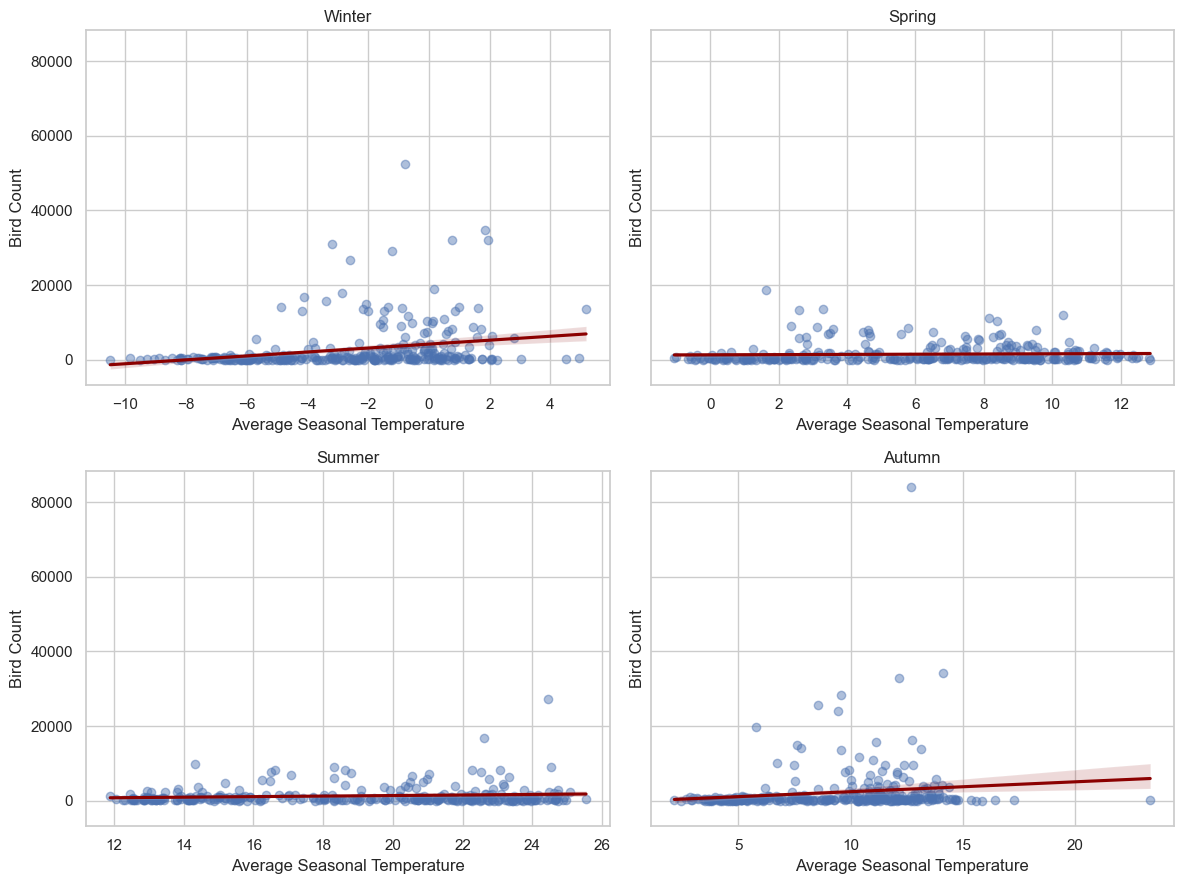

In [34]:
# Season-specific simple regressions for question 1
season_results = []
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

for season_name in season_order:
    season_slice = county_season_df[county_season_df['season'] == season_name].copy()
    season_lr = LinearRegression()
    season_lr.fit(season_slice[['avg_season_temp']], season_slice['bird_count'])

    season_results.append({
        'season': season_name,
        'slope': season_lr.coef_[0],
        'intercept': season_lr.intercept_,
        'r2': season_lr.score(season_slice[['avg_season_temp']], season_slice['bird_count']),
        'corr': season_slice['avg_season_temp'].corr(season_slice['bird_count'])
    })

question1_df = pd.DataFrame(season_results)

question1_lines = []
for row in question1_df.itertuples(index=False):
    direction = 'positive' if row.slope > 0 else 'negative'
    strength = 'very weak' if abs(row.corr) < 0.1 else 'weak' if abs(row.corr) < 0.3 else 'moderate'
    question1_lines.append(
        f"- **{row.season}:** The estimated relationship is **{direction}**, with a slope of **{row.slope:.2f} birds per 1 degree change in average seasonal temperature**. "
        f"The correlation is **{row.corr:.3f}**, which suggests a **{strength}** linear relationship, and the simple-regression R^2 is **{row.r2:.3f}**."
    )

joined_lines = chr(10).join(question1_lines)
question1_markdown = f"""### Question 3 Interpretation

{joined_lines}
"""
render_markdown(question1_markdown)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
for ax, season_name in zip(axes.flatten(), season_order):
    season_slice = county_season_df[county_season_df['season'] == season_name]
    sns.regplot(data=season_slice, x='avg_season_temp', y='bird_count', scatter_kws={'alpha': 0.45}, line_kws={'color': 'darkred'}, ax=ax)
    ax.set_title(season_name)
    ax.set_xlabel('Average Seasonal Temperature')
    ax.set_ylabel('Bird Count')
plt.tight_layout()
plt.show()


In [35]:
coefficient_summary = pd.DataFrame({
    'feature': selected_feature_names,
    'coefficient': best_model.coef_
}).sort_values(by='coefficient', key=lambda s: s.abs(), ascending=False)

key_effects = coefficient_summary[
    coefficient_summary['feature'].str.contains(
        'avg_season_temp|annual_precipitation|urban_population_level|is_fire|is_flood|natural_disaster_months|county_'
    )
].copy()

display(key_effects.head(20))

key_effect_lookup = dict(zip(key_effects['feature'], key_effects['coefficient']))
temp_coef = key_effect_lookup.get('num__avg_season_temp', np.nan)
precip_coef = key_effect_lookup.get('num__annual_precipitation', np.nan)
urban_coef = key_effect_lookup.get('num__urban_population_level', np.nan)
fire_coef = key_effect_lookup.get('num__is_fire', np.nan)
flood_coef = key_effect_lookup.get('num__is_flood', np.nan)
disaster_months_coef = key_effect_lookup.get('num__natural_disaster_months', np.nan)
retained_counties = [f for f in selected_feature_names if 'cat__county_' in f]

render_markdown(
    f"""### Interpretation of key variables' coefficients

- **Average seasonal temperature:** **{temp_coef:.2f}**
- **Annual precipitation:** **{precip_coef:.2f}**
- **Urban population level:** **{urban_coef:.2f}**
- **Fire indicator:** **{fire_coef:.2f}**
- **Flood indicator:** **{flood_coef:.2f}**
- **Natural disaster months:** **{disaster_months_coef:.2f}**

Positive coefficients indicate higher predicted bird counts as the feature increases, while negative coefficients indicate lower predicted counts, holding the other retained variables constant.

The feature-selection step also kept **{len(retained_counties)} county indicator columns**, which means county remains a meaningful part of the final predictive story. That does not mean county is the causal driver of bird counts by itself; instead, it indicates that location still captures residual differences not fully absorbed by temperature, precipitation, disasters, development, and population.
"""
)


,feature,coefficient
3,num__county_total_population,1284.021007
9,cat__county_Boulder,487.635501
2,num__urban_population_level,479.892678
1,num__annual_precipitation,-247.608086
4,num__is_fire,221.960477
0,num__avg_season_temp,-196.683459
5,num__is_flood,-92.509835
6,num__natural_disaster_months,92.160071


### Interpretation of key variables' coefficients

- **Average seasonal temperature:** **-196.68**
- **Annual precipitation:** **-247.61**
- **Urban population level:** **479.89**
- **Fire indicator:** **221.96**
- **Flood indicator:** **-92.51**
- **Natural disaster months:** **92.16**

Positive coefficients indicate higher predicted bird counts as the feature increases, while negative coefficients indicate lower predicted counts, holding the other retained variables constant.

The feature-selection step also kept **1 county indicator columns**, which means county remains a meaningful part of the final predictive story. That does not mean county is the causal driver of bird counts by itself; instead, it indicates that location still captures residual differences not fully absorbed by temperature, precipitation, disasters, development, and population.


## Predicting Effects of Natural Disasters, Urban Development, and Precipitation

We estimate the impact of **natural disasters** by comparing predictions under the observed dataset conditions versus a counterfactual scenario where fire, flood, and disaster-month exposure are set to zero.  
We estimate the impact of **urban development** by replacing the `urban_population_level` feature with values from 1 through 5 and comparing the resulting predicted bird counts.  
We estimate the impact of **annual precipitation** by comparing dry-year and wet-year counterfactual predictions based on the 25th and 75th percentile precipitation levels.

In [36]:
def predict_with_selected_model(df):
    transformed = preprocessor.transform(df)
    transformed = transformed.toarray() if hasattr(transformed, 'toarray') else transformed
    transformed_selected = transformed[:, final_selected_mask]
    return best_model.predict(transformed_selected)


scenario_base = model_df[feature_cols].copy()

scenario_no_disaster = scenario_base.copy()
scenario_no_disaster['is_fire'] = 0
scenario_no_disaster['is_flood'] = 0
scenario_no_disaster['natural_disaster_months'] = 0

observed_pred = predict_with_selected_model(scenario_base)
no_disaster_pred = predict_with_selected_model(scenario_no_disaster)

natural_disaster_impact = pd.DataFrame([
    {
        'scenario': 'Observed disaster conditions',
        'average_predicted_bird_count': observed_pred.mean()
    },
    {
        'scenario': 'Counterfactual with disasters removed',
        'average_predicted_bird_count': no_disaster_pred.mean()
    },
    {
        'scenario': 'Estimated average change if disasters are removed',
        'average_predicted_bird_count': (no_disaster_pred - observed_pred).mean()
    }
])

display(natural_disaster_impact)

urban_scenarios = []
for level in sorted(county_season_df['urban_population_level'].dropna().unique()):
    scenario = scenario_base.copy()
    scenario['urban_population_level'] = level
    urban_scenarios.append({
        'urban_population_level': level,
        'average_predicted_bird_count': predict_with_selected_model(scenario).mean()
    })
urban_impact_df = pd.DataFrame(urban_scenarios)
display(urban_impact_df)

dry_precip = county_season_df['annual_precipitation'].quantile(0.25)
wet_precip = county_season_df['annual_precipitation'].quantile(0.75)

scenario_dry = scenario_base.copy()
scenario_dry['annual_precipitation'] = dry_precip
scenario_wet = scenario_base.copy()
scenario_wet['annual_precipitation'] = wet_precip

precip_impact_df = pd.DataFrame([
    {
        'scenario': f'Dry-year precipitation (25th percentile = {dry_precip:.2f})',
        'average_predicted_bird_count': predict_with_selected_model(scenario_dry).mean()
    },
    {
        'scenario': f'Wet-year precipitation (75th percentile = {wet_precip:.2f})',
        'average_predicted_bird_count': predict_with_selected_model(scenario_wet).mean()
    },
    {
        'scenario': 'Estimated average change from dry-year to wet-year precipitation',
        'average_predicted_bird_count': (predict_with_selected_model(scenario_wet) - predict_with_selected_model(scenario_dry)).mean()
    }
])
display(precip_impact_df)

urban_lines = []
for row in urban_impact_df.itertuples(index=False):
    urban_lines.append(f"- Urban population level **{row.urban_population_level:.0f}** corresponds to an average predicted bird count of **{row.average_predicted_bird_count:.2f}**.")

urban_text = chr(10).join(urban_lines)
scenario_markdown = f"""### Interpretation of Prediction Results from Natural Disasters

The model predicts an average bird count of **{natural_disaster_impact.iloc[0, 1]:.2f}** under the observed disaster conditions in the test set. When fire and flood indicators are set to zero and disaster-month exposure is removed, the average predicted bird count becomes **{natural_disaster_impact.iloc[1, 1]:.2f}**. The estimated mean change is **{natural_disaster_impact.iloc[2, 1]:.2f}** birds, which indicates that removing disaster exposure leads to a **{'decrease' if natural_disaster_impact.iloc[2, 1] < 0 else 'increase'}** in predicted counts in this model configuration.

### Interpretation of Prediction Results from Urban Development

{urban_text}

Across these scenarios, the predictions increase as the urban population level rises, so the model associates higher urban-development levels with higher expected bird counts after controlling for the other included variables.

### Interpretation of Prediction Results from Annual Precipitation

Under the dry-year scenario, the average predicted bird count is **{precip_impact_df.iloc[0, 1]:.2f}**. Under the wet-year scenario, it is **{precip_impact_df.iloc[1, 1]:.2f}**. The average shift from the dry-year to wet-year setting is **{precip_impact_df.iloc[2, 1]:.2f}** birds, which suggests that higher annual precipitation is associated with **{'lower' if precip_impact_df.iloc[2, 1] < 0 else 'higher'}** predicted bird counts in this regression setup.
"""
render_markdown(scenario_markdown)


,scenario,average_predicted_bird_count
0,Observed disaster conditions,1932.606108
1,Counterfactual with disasters removed,1915.236547
2,Estimated average change if disasters are removed,-17.369561


,urban_population_level,average_predicted_bird_count
0,1.0,1460.723336
1,2.0,1759.037346
2,3.0,2057.351356
3,4.0,2355.665366
4,5.0,2653.979376


,scenario,average_predicted_bird_count
0,Dry-year precipitation (25th percentile = 342.37),2111.608307
1,Wet-year precipitation (75th percentile = 520.30),1773.903032
2,Estimated average change from dry-year to wet-...,-337.705274


### Interpretation of Prediction Results from Natural Disasters

The model predicts an average bird count of **1932.61** under the observed disaster conditions in the test set. When fire and flood indicators are set to zero and disaster-month exposure is removed, the average predicted bird count becomes **1915.24**. The estimated mean change is **-17.37** birds, which indicates that removing disaster exposure leads to a **decrease** in predicted counts in this model configuration.

### Interpretation of Prediction Results from Urban Development

- Urban population level **1** corresponds to an average predicted bird count of **1460.72**.
- Urban population level **2** corresponds to an average predicted bird count of **1759.04**.
- Urban population level **3** corresponds to an average predicted bird count of **2057.35**.
- Urban population level **4** corresponds to an average predicted bird count of **2355.67**.
- Urban population level **5** corresponds to an average predicted bird count of **2653.98**.

Across these scenarios, the predictions increase as the urban population level rises, so the model associates higher urban-development levels with higher expected bird counts after controlling for the other included variables.

### Interpretation of Prediction Results from Annual Precipitation

Under the dry-year scenario, the average predicted bird count is **2111.61**. Under the wet-year scenario, it is **1773.90**. The average shift from the dry-year to wet-year setting is **-337.71** birds, which suggests that higher annual precipitation is associated with **lower** predicted bird counts in this regression setup.


## Challenges Faced and Solutions

Challenges:
- The original dataset is observation-level, so weather and disaster values repeat many times across bird records.
- County overlaps with climate, development, and disaster variables, but it can still carry additional location-specific signal.
- One-hot encoding county creates many extra predictors, some of which are likely weak or redundant.
- A fully unconstrained feature-selection step can potentially drop variables tied directly to the research questions.

Solutions:
- Aggregated the data to county-month and county-season levels before modeling.
- Added a feature-selection step using `LassoCV`, but kept variables directly related to the research questions in the final design matrix.
- Compared a plain linear regression baseline with a tuned Ridge regression after feature selection.


**Note:** The model takes observational data as input and does not fully represent bird populations in Colorado. These results should still be interpreted as predictive relationships and controlled associations rather than definitive causal claims.